# Seleccion de Variables con Lasso por regla de un desvio estandar


En el presente notebook se generan y se evalúan los siguientes modelos.

* Regresión lineal Lasso
* Regresión lineal
* Ridge
* Árbol de regresión
* KNN para regresión
* Regresión no paramétrica

El preprocesamiento principal se realiza mediante una seleccion de variables utilizando el metodo de regresion Lasso. 

In [22]:
library(pracma)
library(glmnet)
library("stats")
library("partykit")
library(ggplot2)
source("Utils.R")
library(MASS)

In [3]:
library(reticulate)
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)

StScaler <- import("sklearn.preprocessing", convert = FALSE)$StandardScaler
MMScaler <- import("sklearn.preprocessing", convert = FALSE)$MinMaxScaler

### Division de los datos

In [4]:
setSeed()

vasijas_X <- obtener_X()
vasijas_Y <- obtener_Y()

df <- vasijas_X
df$Y <- vasijas_Y


hold_out_ind <- obtener_holdout_ind(vasijas_X)

HOLDOUT_X <- vasijas_X[hold_out_ind, ]
HOLDOUT_Y <- vasijas_Y[hold_out_ind]
HOLDOUT_DF <- df[hold_out_ind, ]

TRAIN_Y <- vasijas_Y[-hold_out_ind]
TRAIN_X <- vasijas_X[-hold_out_ind, ]
TRAIN_DF <- df[-hold_out_ind, ]

# Seleccion de Variables con Lasso

### Modelo sin tuneo de parametros y sin escalar 

In [5]:
model <- glmnet(as.matrix(TRAIN_X), TRAIN_Y, alpha=1)

In [6]:
Y_pred = predict(model, as.matrix(TRAIN_X))
error_min <- sum((TRAIN_Y - Y_pred[, 1])^2) / nrow(TRAIN_X)
best_model <- 1
for (i in 2:ncol(Y_pred)) {
    curr_error <- sum((TRAIN_Y - Y_pred[, i])^2) / nrow(TRAIN_X)
    if (curr_error < error_min) {
        error_min <- curr_error 
        best_model <- i
    }
}
print(paste("El error cuadratico medio de train es: ", error_min, " usando el modelo numero: ", best_model))

[1] "El error cuadratico medio de train es:  0.694377895643682  usando el modelo numero:  100"


In [7]:
best_lambda = model$lambda[100]
print(paste("El lambda utilizado es: ", best_lambda))

[1] "El lambda utilizado es:  0.0372287988245699"


In [8]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
err = 0
for(i in indices){

    X_train_scaled = X[-i,]
    Y_train = TRAIN_Y[-i]

    X_test_scaled = X[i,]
    Y_test = TRAIN_Y[i]

    model <- glmnet(as.matrix(X_train_scaled), Y_train, alpha=1, lambda = best_lambda)
    Y_pred = predict(model, as.matrix(X_test_scaled))
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  1.26012561111025"


### Busqueda del mejor lambda con la regla de un desvio estandar (mas parsimonioso)

In [9]:
setSeed()
escalador <- MMScaler()
X_train_scaled <- as.matrix(escalador$fit_transform(TRAIN_X))
cv_result <- cv.glmnet(X_train_scaled, TRAIN_Y, alpha = 1, lambda = logspace(-4, 0, 100), nfolds = 5)

Los mejores parámetros obtenidos fueron entonces:

In [10]:
lambda_optimo <- cv_result$lambda.1se
lambda_min <- cv_result$lambda.min
lambda_optimo

[1] 0.02009233

In [11]:
a <- data.frame(
    Lambda <-  cv_result$lambda,
    SD <- cv_result$cvsd,
    Y <- cv_result$cvm,
    color <- sapply(cv_result$lambda, function(x) 
                (ifelse(x==lambda_optimo, "LambdaOp", ifelse(x==lambda_min, "LambdaMin", "Nada"))))
)
colnames(a) <- c("Lambda", "SD", "ECMCV", "Color")

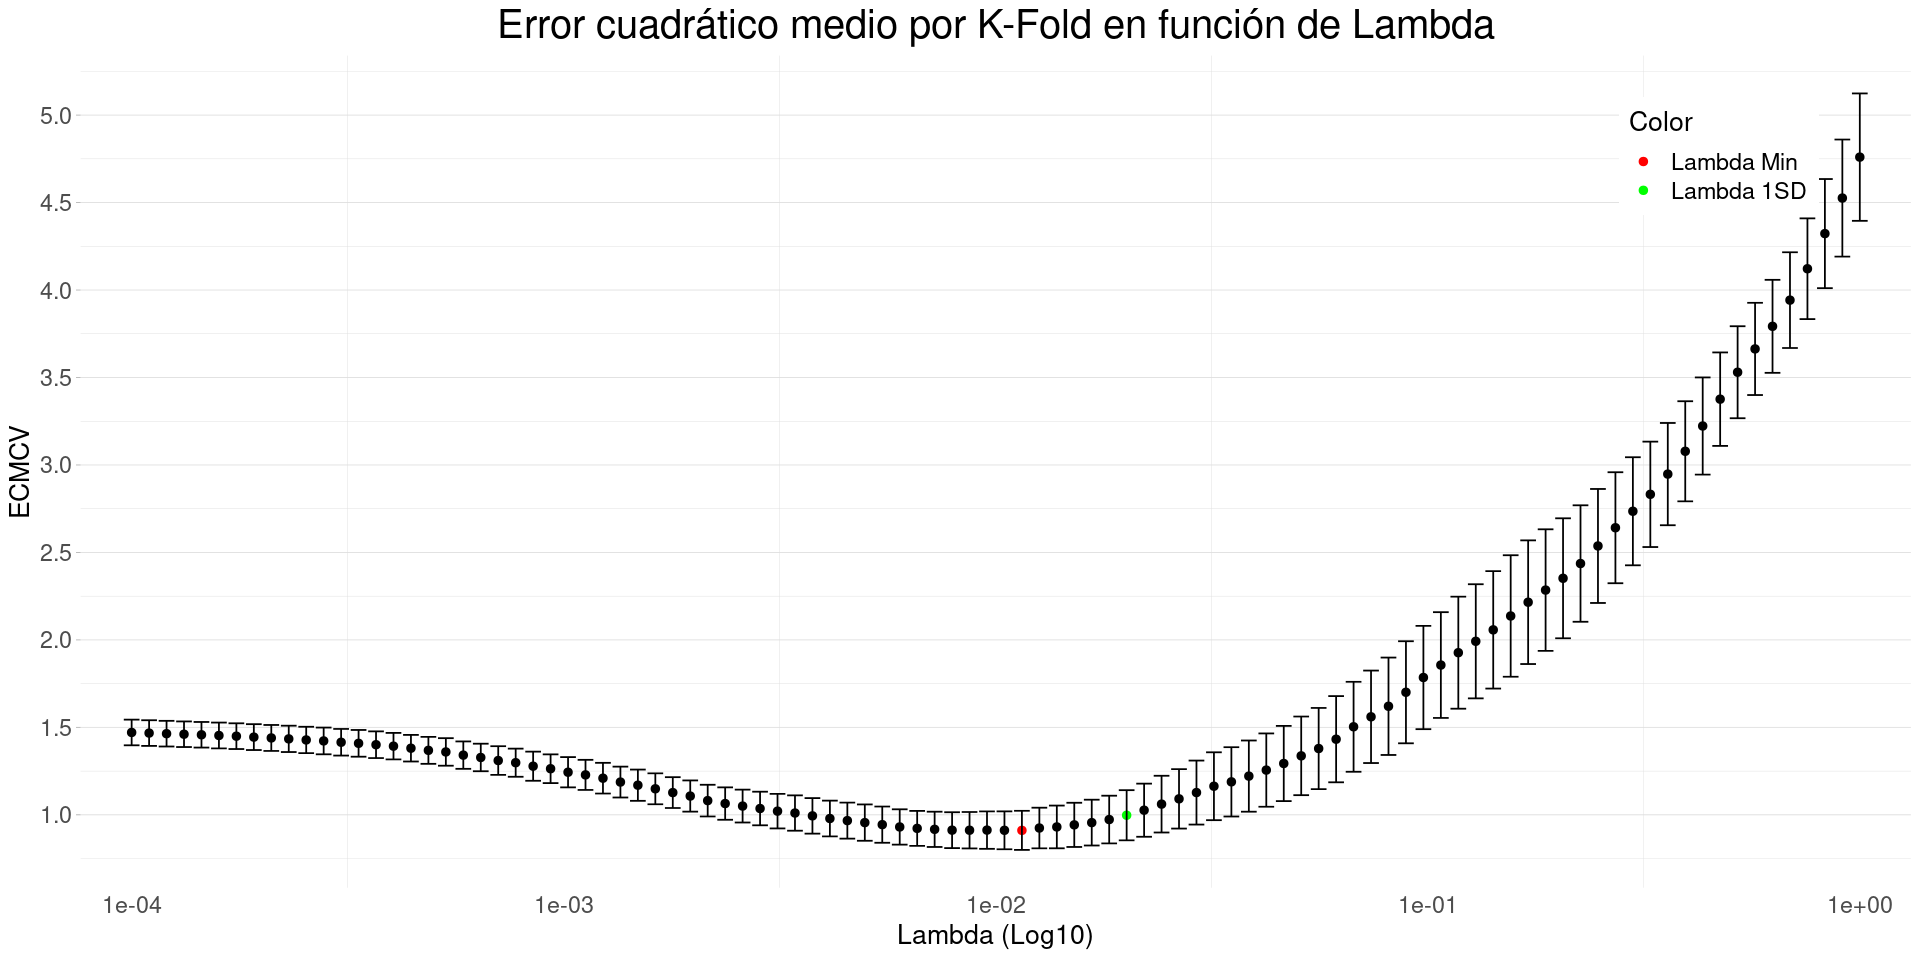

In [12]:
options(repr.plot.width=16, repr.plot.height=8)

ggplot(a, aes(x = Lambda, y = ECMCV)) + 
  ggtitle("Error cuadrático medio por K-Fold en función de Lambda") +
  geom_point(aes(x = Lambda, y = ECMCV,color = Color), size = 2) + 
  geom_errorbar(aes(ymin = ECMCV - SD, ymax = ECMCV + SD)) +
  theme_light() +
  scale_colour_manual(values = c("LambdaMin" = "red", "LambdaOp" = "Green", "Nada" = "Black"),
                      labels = c("Lambda Min", "Lambda 1SD"), breaks = c("LambdaMin", "LambdaOp")) + 
  theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank(),
        legend.position = c(.95, .95),
        legend.justification = c("right", "top"),
        legend.box.just = "right",
        legend.margin = margin(6, 6, 6, 6),
        legend.title = element_text(size=16),
        legend.text = element_text(size=14)) +
  scale_x_continuous(trans = 'log10',  expand = c(0,0.1), breaks = logspace(-6, 0, 7)) +
  scale_y_continuous(breaks = seq(0, 6, by=0.5)) +
  xlab("Lambda (Log10)") + ylab("ECMCV")

### Calculo del error por LOOCV

In [13]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
err = 0
escalador = MMScaler()
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    model <- glmnet(X_train_scaled, Y_train, lambda=lambda_optimo, alpha=1)
    Y_pred = predict(model, X_test_scaled)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.928382347302504"


In [14]:
X_scaled <- as.matrix(escalador$fit_transform(TRAIN_X))
X_holdout_scaled_modelo_1 = as.matrix(escalador$transform(HOLDOUT_X))
modelo1 <- glmnet(X_scaled, TRAIN_Y, alpha=1, lambda=lambda_optimo)

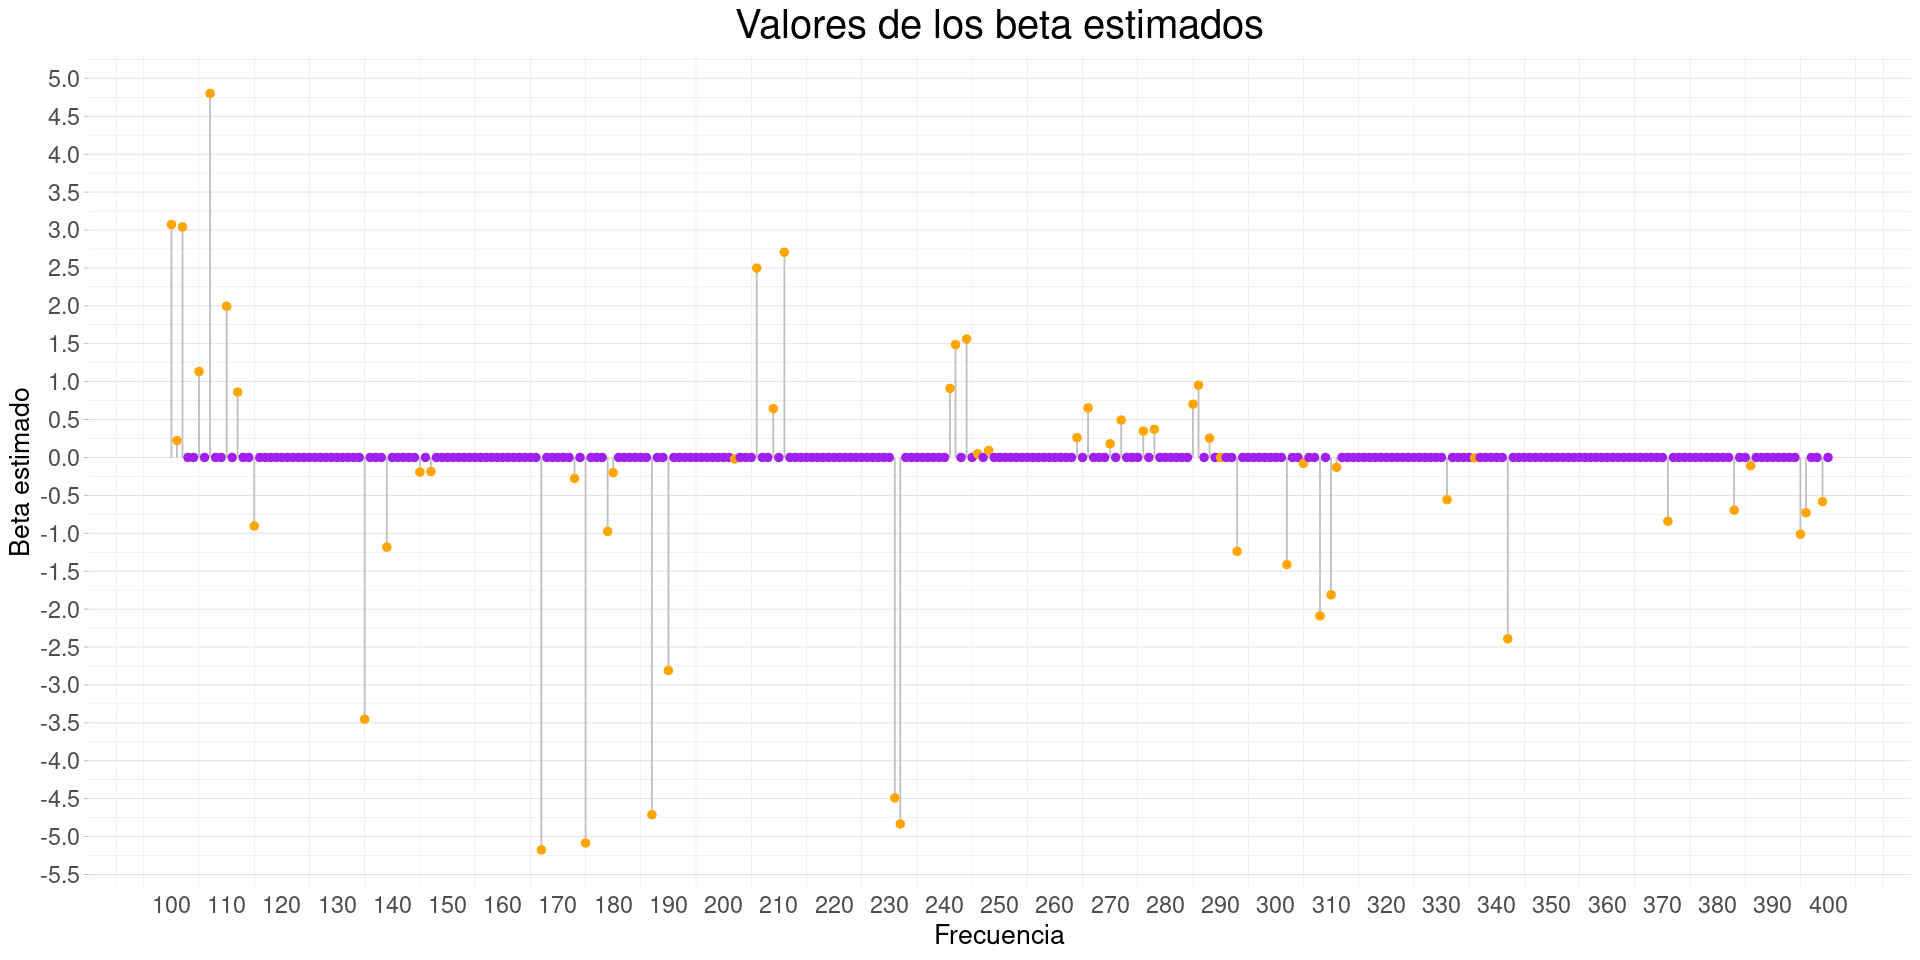

In [15]:
x_plot = as.integer(sub('.', '', colnames(TRAIN_X))) + 99

data_plot <- data.frame(
  x=x_plot,
  y=modelo1$beta[,1]
)


# Plot

options(repr.plot.width=16, repr.plot.height=8)

colores = sapply(modelo1$beta[,1], function(x) (ifelse(x!=0, "orange",  "purple")))
ggplot(data_plot, aes(x=x, y=y)) +
  ggtitle("Valores de los beta estimados") +
  geom_segment( aes(x=x, xend=x, y=0, yend=y), color="grey") +
  geom_point(color=colores, size=2) +
  theme_light() +
  theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank()) +
  scale_x_continuous(breaks = seq(100, 400, by=10)) +
  scale_y_continuous(breaks = seq(-6, 6, by=0.5)) +
  xlab("Frecuencia") + ylab("Beta estimado")

In [16]:
variables_to_filter = modelo1$beta[,1] != 0
print(paste("El mejor modelo de Lasso encontrado elimino ", sum(modelo1$beta[,1] == 0), " variables"))
print(paste("El mejor modelo de Lasso encontrado se quedo con ", sum(modelo1$beta[,1] != 0), " variables"))

[1] "El mejor modelo de Lasso encontrado elimino  246  variables"
[1] "El mejor modelo de Lasso encontrado se quedo con  55  variables"


In [17]:
p = sum(modelo1$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

[1] "R2 adj =   0.919501320775621"


In [18]:
SELECTED_TRAIN_X <- TRAIN_X[, variables_to_filter]
SELECTED_TRAIN_DF <- SELECTED_TRAIN_X
SELECTED_TRAIN_DF$Y <- TRAIN_Y

SELECTED_HOLDOUT_X <- HOLDOUT_X[, variables_to_filter]
SELECTED_HOLDOUT_DF <- SELECTED_HOLDOUT_X
SELECTED_HOLDOUT_DF$Y <- HOLDOUT_Y

# Modelo 2: Regresion Lineal

In [19]:
# No escalamos los datos porque no hay regularizacion.
modelo2 <- lm(Y~., data = SELECTED_TRAIN_DF)

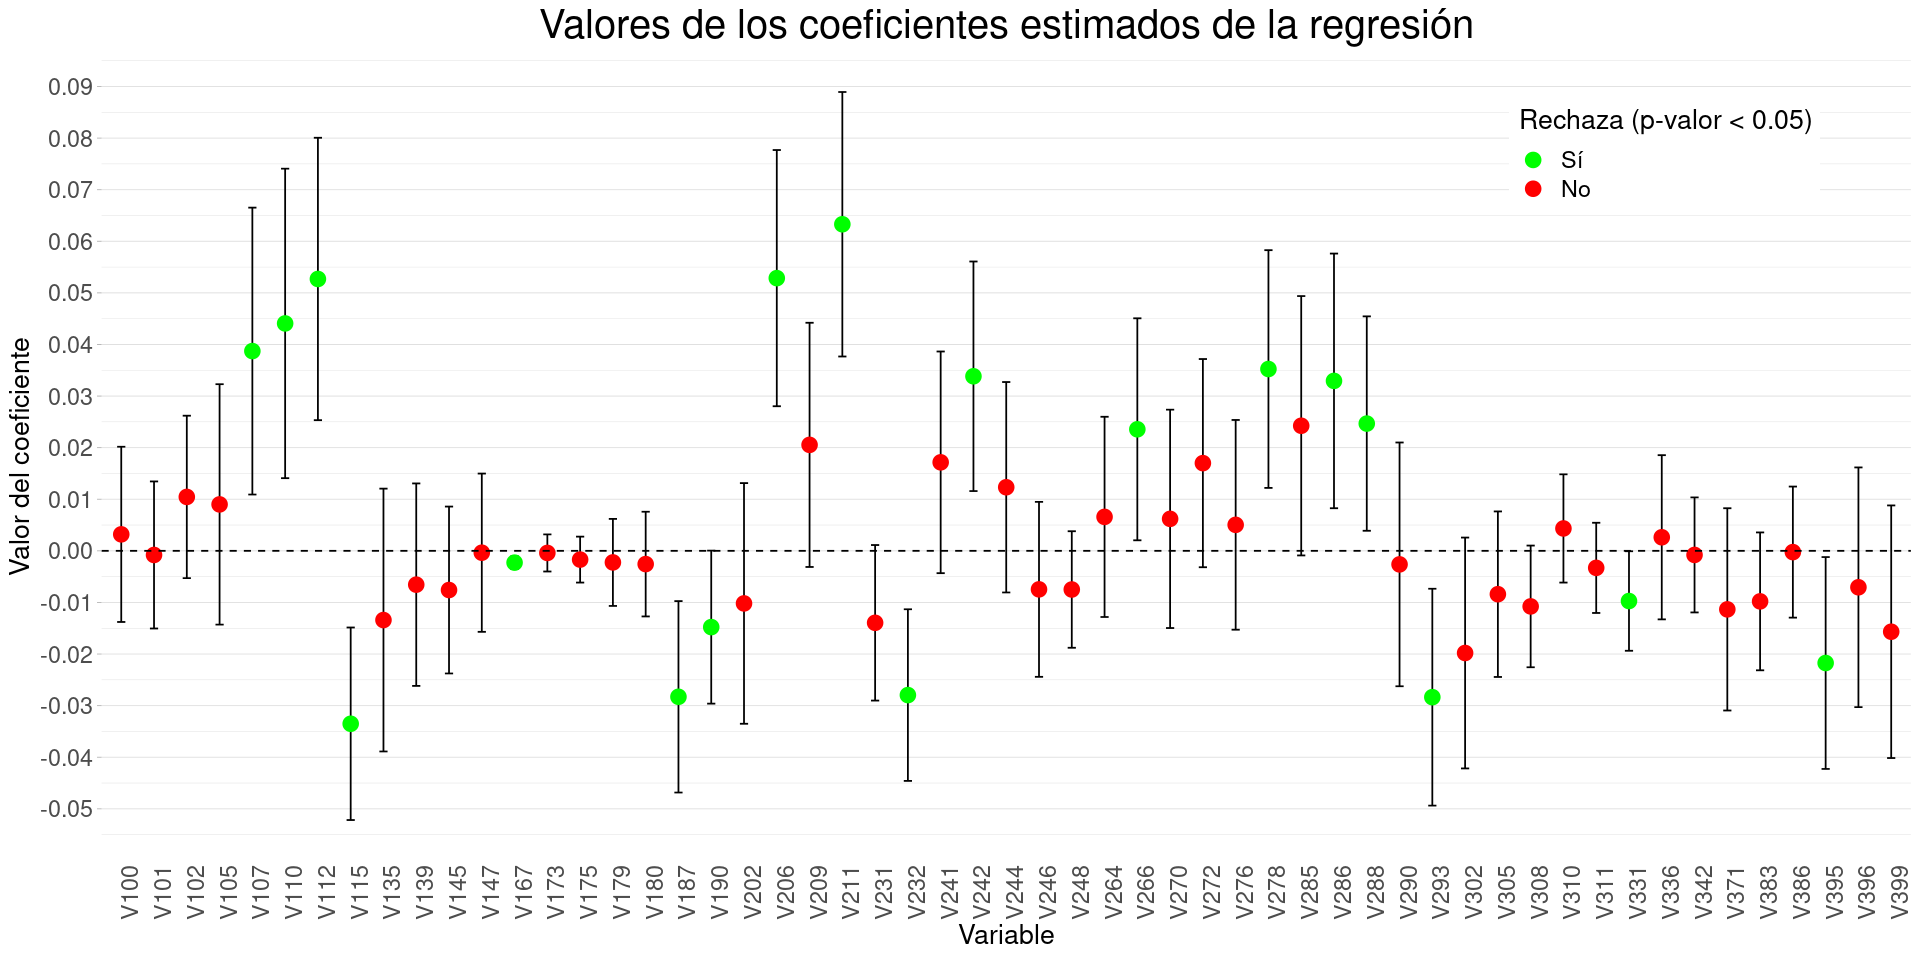

In [20]:
a <- summary(modelo2)
x_plot = paste("V", as.integer(sub('.', '', colnames(SELECTED_TRAIN_X))) + 99, sep="")
data_plot <- data.frame(
    x=x_plot,
    y=a$coefficients[-1, 1],
    sd=a$coefficients[-1, 2],
    col=(a$coefficients[-1, 4] < 0.05)
)
colnames(data_plot) <- c("V", "Estimate", "SD", "Rechaza")

options(repr.plot.width=16, repr.plot.height=8)

ggplot(data_plot, aes(x = V, y = Estimate)) + 
  ggtitle("Valores de los coeficientes estimados de la regresión") +
  geom_errorbar(aes(ymin = Estimate - 2*SD, ymax = Estimate + 2*SD),  width=0.25) +
  geom_point(aes(color = Rechaza), size = 4) + 
  theme_light() +
  scale_colour_manual(values = c("TRUE" = "green", "FALSE" = "red"),
                      labels = c("Sí", "No"), breaks = c("TRUE", "FALSE")) + 
  theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text.y=element_text(size=14),
        axis.text.x=element_text(size=14, angle = 90),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank(),
        legend.position = c(.95, .95),
        legend.justification = c("right", "top"),
        legend.box.just = "right",
        legend.margin = margin(6, 6, 6, 6),
        legend.title = element_text(size=16),
        legend.text = element_text(size=14)) +
  geom_hline(yintercept=0, linetype="dashed") + 
  guides(color=guide_legend("Rechaza (p-valor < 0.05)")) +
  scale_y_continuous(breaks = seq(-1, 1, by=0.01)) +
  xlab("Variable") + ylab("Valor del coeficiente")

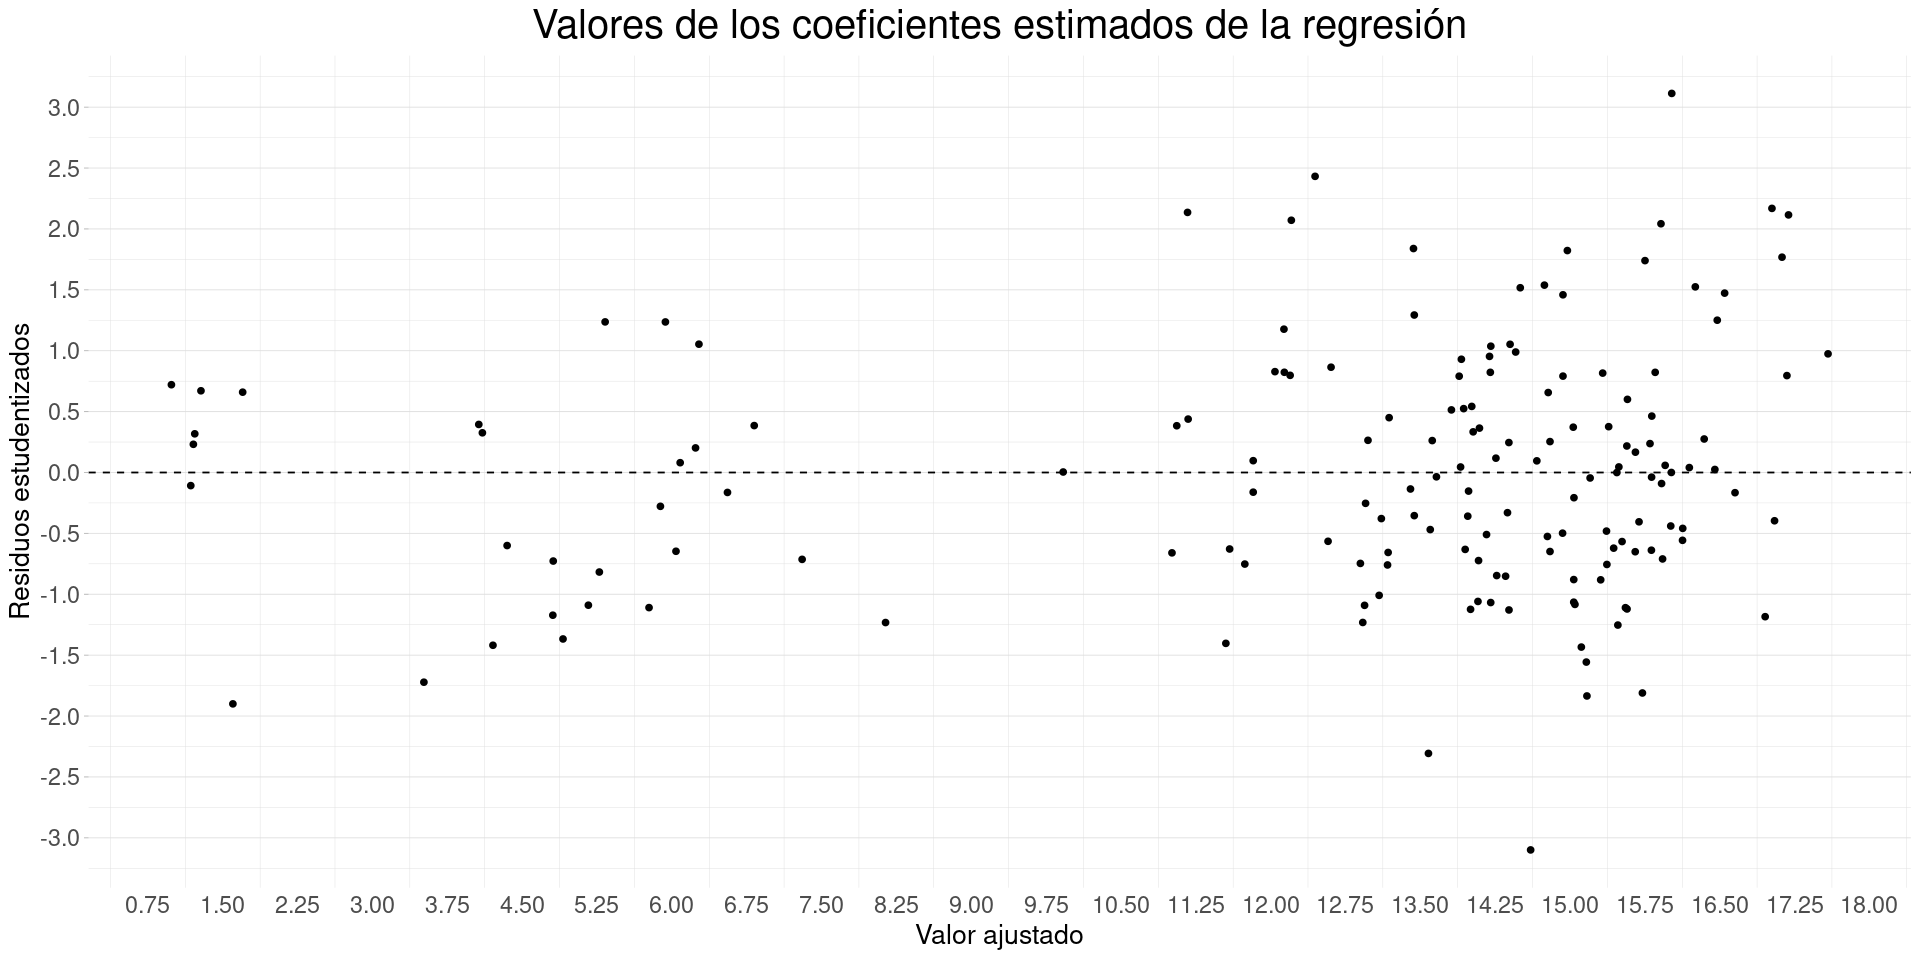

In [23]:
b <- data.frame(
    "y" = SELECTED_TRAIN_DF$Y,
    "tmenosi" = studres(modelo2)
)
options(repr.plot.width=16, repr.plot.height=8)
ggplot(b, aes(x=y, y=tmenosi)) +
    ggtitle("Valores de los coeficientes estimados de la regresión") +
    geom_point()+
    theme_light() +
    theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank()) +
    geom_hline(yintercept=0, linetype="dashed") + 
    scale_x_continuous(breaks = seq(0, 20, by=0.75)) +
    scale_y_continuous(breaks = seq(-4, 4, by=0.5)) + 
    xlab("Valor ajustado") + ylab("Residuos estudentizados")

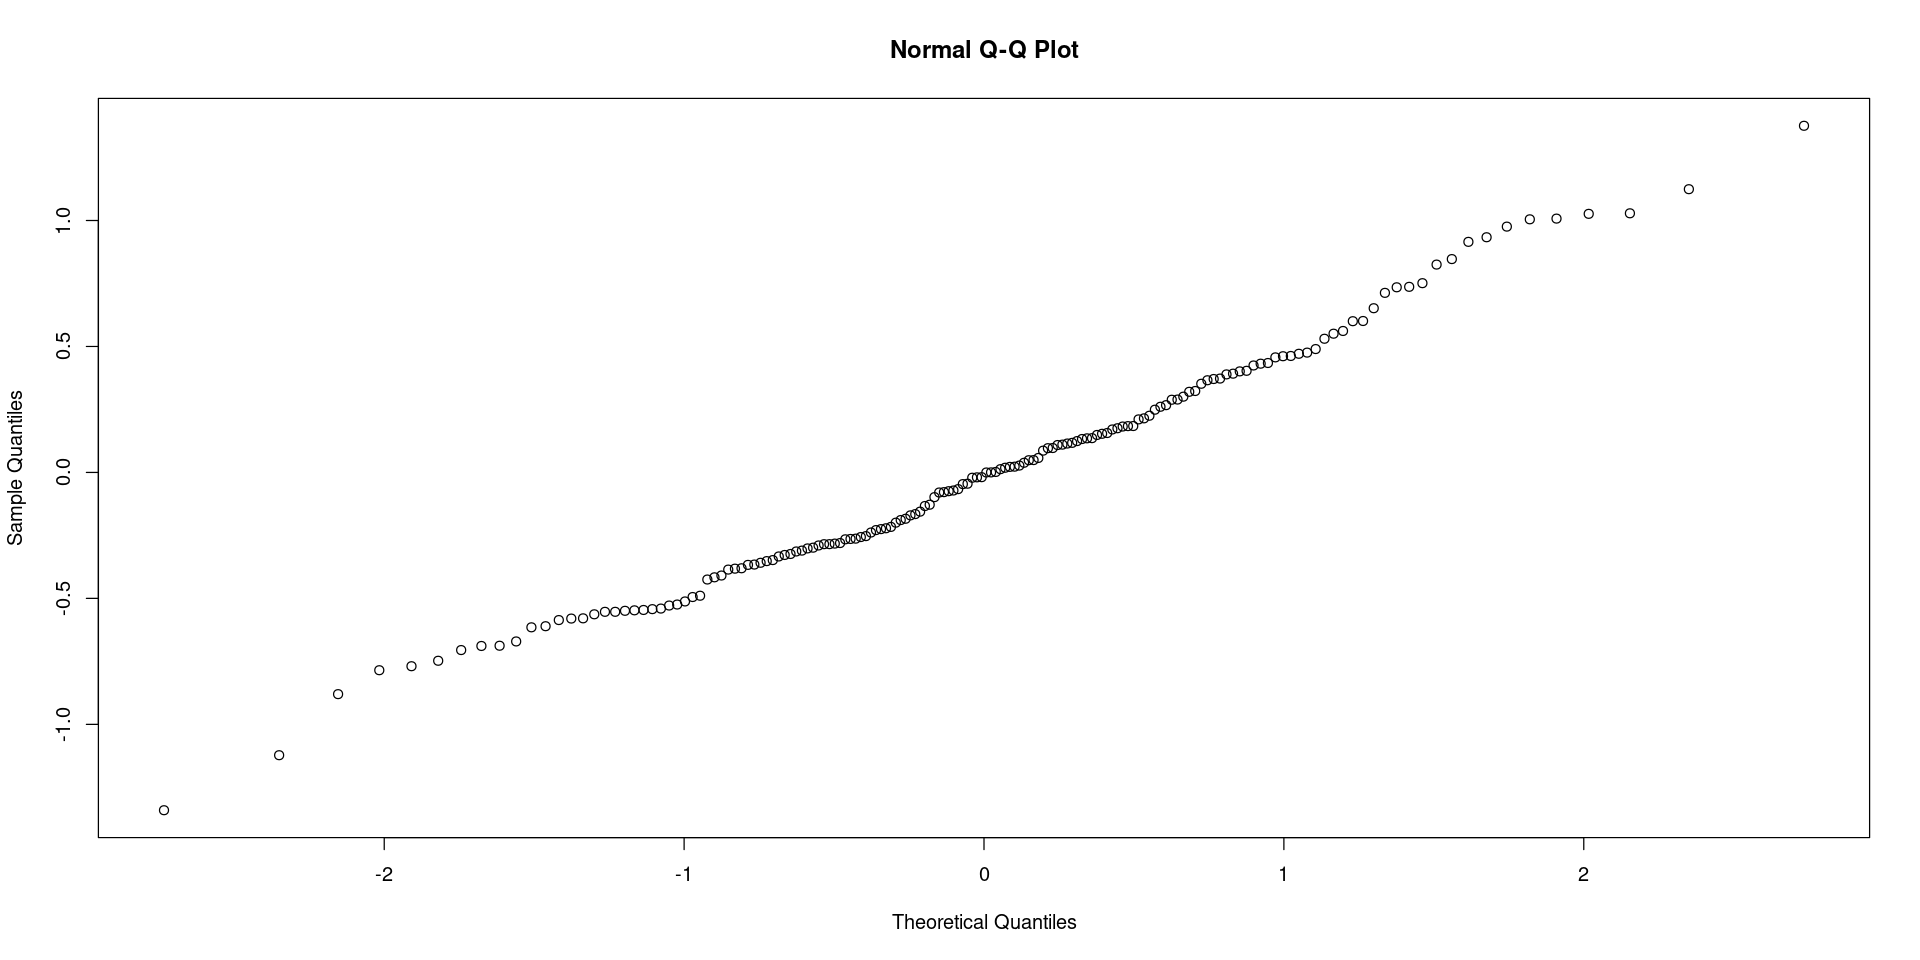

In [24]:
data_plot <- as.data.frame(qqnorm(modelo2$residuals))

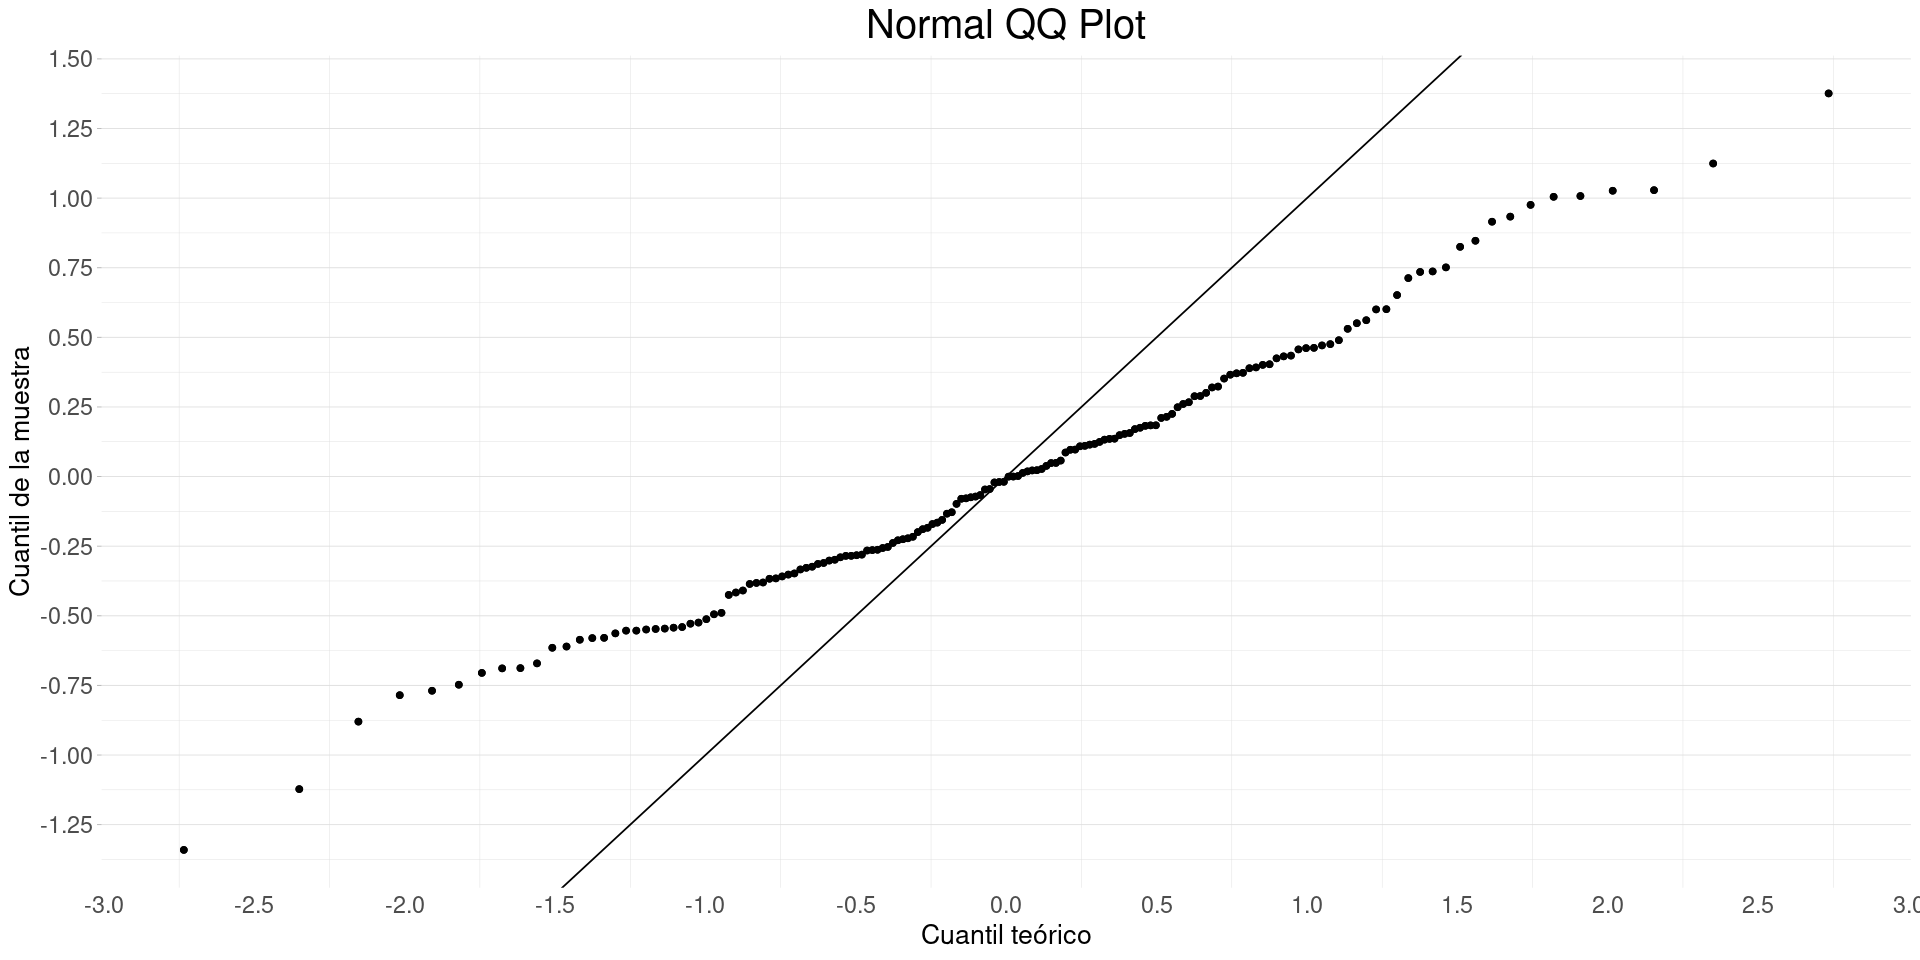

In [25]:
options(repr.plot.width=16, repr.plot.height=8)

ggplot(data_plot, aes(x=x, y=y)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0) +
    ggtitle("Normal QQ Plot") +
    geom_point()+
    theme_light() +
    theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank()) +
    xlab("Cuantil teórico") + ylab("Cuantil de la muestra")+
    scale_x_continuous(breaks = seq(-5, 5, by=0.5)) +
    scale_y_continuous(breaks = seq(-2, 2, by=0.25))

In [ ]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){
    df_train = X[-i,]
    df_train$Y = TRAIN_Y[-i]
    
    X_test = X[i,]
    Y_test = TRAIN_Y[i]

    model <- lm(Y~.,  data = df_train)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

In [ ]:
p = sum(modelo1$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

In [ ]:
plot(modelo2)

# Modelo 3: Regresion Lineal Regularizada

### Sólo iterando lambda y sin escalar

In [ ]:
model <- glmnet(as.matrix(SELECTED_TRAIN_X), TRAIN_Y)

In [ ]:
Y_pred = predict(model, as.matrix(SELECTED_TRAIN_X))
error_min <- sum((TRAIN_Y - Y_pred[, 1])^2) / nrow(SELECTED_TRAIN_X)
best_model <- 1
for (i in 2:ncol(Y_pred)) {
    curr_error <- sum((TRAIN_Y - Y_pred[, i])^2) / nrow(SELECTED_TRAIN_X)
    if (curr_error < error_min) {
        error_min <- curr_error 
        best_model <- i
    }
}
print(paste("El error cuadratico medio de train es: ", error_min, " usando el modelo numero: ", best_model))

In [ ]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){

    X_train_scaled = X[-i,]
    Y_train = TRAIN_Y[-i]

    X_test_scaled = X[i,]
    Y_test = TRAIN_Y[i]

    model <- glmnet(as.matrix(X_train_scaled), Y_train, lambda=0.0372, alpha=1)
    Y_pred = predict(model, as.matrix(X_test_scaled))
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

### Busqueda de los parametros de la prediccion

In [ ]:
setSeed()
n = nrow(SELECTED_TRAIN_X)
k = 5
resultados <- data.frame(
  Alpha   =double(),
  Lambda  =double(),
  Escalador = integer(),
  Error   =double()
)

indices = obtener_indices_kfold(n, k)
X <- SELECTED_TRAIN_X

alphas <- seq(0, 1, 0.05)
lambdas <- logspace(-10, 3, 50)
escaladores <- c(StScaler(), MMScaler())


for (alpha in alphas) {
    for (lambda in lambdas) {
        for(s in 1:length(escaladores)){
            escalador = escaladores[[s]] 
            err = 0
            for (i in indices) {
                X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
                Y_train = TRAIN_Y[-i]

                X_test_scaled = as.matrix(escalador$transform(X[i, ]))
                Y_test = TRAIN_Y[i]

                model <- glmnet(X_train_scaled, Y_train, lambda=lambda, alpha=alpha)
                Y_pred = predict(model, X_test_scaled)
                err = err + sum((Y_test - Y_pred)^2)
            }
            resultados = rbind(resultados, list(alpha, lambda, s, err/n))
        }
    }
    message(progreso(alpha, alphas))
}

colnames(resultados)  <- c("alpha", "lambda", "Escalador", "Error")

Los mejores parámetros obtenidos fueron entonces:

In [ ]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

### Calculo del error por LOOCV

In [ ]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
escalador = escaladores[[mejores_parametros$Escalador]]
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    model <- glmnet(X_train_scaled, Y_train, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)
    Y_pred = predict(model, X_test_scaled)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

In [ ]:
X_train_scaled <- as.matrix(escalador$fit_transform(X))
X_holdout_scaled_modelo3 <- as.matrix(escalador$transform(SELECTED_HOLDOUT_X))
modelo3 <- glmnet(X_train_scaled, TRAIN_Y, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)

p = sum(modelo3$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

In [ ]:
p

No elimino ninguno

# Modelo 4: árbol de regresión

### Busqueda de los parametros de la prediccion

In [ ]:
library(rpart)
library(rpart.plot)

In [ ]:
setSeed()

n = nrow(SELECTED_TRAIN_X)
k = 10

resultados <- data.frame(
  Minsplit =double(),
  Maxdepth =double(),
  CP       =double(),
  Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- SELECTED_TRAIN_X

minsplits <- c(2, 5, 10, 20, 30, 50)

for (minsplit in minsplits) {
    for (maxdepth in c(4, 5, 6, 7, 8)) {
        for (cp in c(0.0005, 0.001, 0.005, 0.01, 0.015, 0.025)) {
            parametros = rpart.control(minsplit=minsplit, maxdepth=maxdepth, cp=cp)
            err = 0
            for(i in indices) {
                DF_train = X[-i,]
                DF_train$Y = TRAIN_Y[-i]

                DF_test = X[i,]
                DF_test$Y = TRAIN_Y[i]
                
                model <- rpart(Y ~ ., data = DF_train, control=parametros, xval=1)
                Y_pred = predict(model, DF_test)
                err = err + sum((DF_test$Y - Y_pred)^2)
            }
            resultados = rbind(resultados, list(minsplit, maxdepth, cp, err/n))
        }
    }
    message(progreso(minsplit, minsplits))
}

colnames(resultados)  <- c("Minsplit", "Maxdepth", "CP", "Error")

In [ ]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

### Calculo del error

In [ ]:
parametros <- rpart.control(minsplit=mejores_parametros$Minsplit, maxdepth=mejores_parametros$Maxdepth, cp=mejores_parametros$CP)

modelo4 <- rpart(Y ~ ., data = SELECTED_TRAIN_DF, control=parametros)

In [ ]:
rpart.plot(modelo4, digits=4)
title("Modelo 16")

In [ ]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){
    train_df <- X[-i,]
    train_df$Y <- TRAIN_Y[-i]
    X_test <- X[i,]
    Y_test = TRAIN_Y[i]

    model <- rpart(Y ~ ., data = train_df, control=parametros)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

In [ ]:
p <- length(unique(summary(modelo4)$frame$var))-1

In [ ]:
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

# Modelo 5: KNN para regresión

In [ ]:
library(reticulate)

In [ ]:
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)

In [ ]:
knnr <- import("sklearn.neighbors", convert = FALSE)$KNeighborsRegressor

### Sin tuneo de parametros

In [ ]:
model <- knnr()$fit(SELECTED_TRAIN_X, TRAIN_Y)

In [ ]:
Y_pred = as.double(model$predict(SELECTED_TRAIN_X))
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(SELECTED_TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))

### Busqueda de los parametros de la prediccion

In [ ]:
setSeed()

n = nrow(SELECTED_TRAIN_X)
k = 10

resultados <- data.frame(
    K        =integer(),
    Weights  =integer(),
    p        =integer(),
    S        =integer(),
    Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- SELECTED_TRAIN_X
escaladores <- c(StScaler(), MMScaler())
for(K in 1:10){
    for(w in c(1, 2)){
        wei = ifelse(w==1, "uniform", "distance")
        for(p in c(1, 2)){
            for(s in 1:length(escaladores)){
                escalador = escaladores[[s]]
                err = 0
                for(i in indices){
                    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
                    Y_train = TRAIN_Y[-i]

                    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
                    Y_test = TRAIN_Y[i]
                    
                    model <- knnr(n_neighbors=K, p=p, weights=wei)$fit(X_train_scaled, Y_train)
                    Y_pred = as.double(model$predict(X_test_scaled))
                    err = err + sum((Y_test - Y_pred)^2)
                }
                resultados = rbind(resultados, list(K, w, p, s, err/n))
            }
        }
    }
    message(progreso(K, 1:10))
}
colnames(resultados)  <- c("K", "Weights", "Distance", "Escalador", "Error")

In [ ]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

### Calculo del error

In [ ]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
escalador = escaladores[[mejores_parametros$Escalador]]
wei <- ifelse(mejores_parametros$Weights==1, "uniform", "distance")
err = 0
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    model <- knnr(n_neighbors=mejores_parametros$K, p=mejores_parametros$Distance, weights=wei)$fit(X_train_scaled, Y_train)
    Y_pred = as.double(model$predict(X_test_scaled))
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

In [ ]:
p = sum(modelo1$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
hatY

In [ ]:
escalador = escaladores[[mejores_parametros$Escalador]]
X_train_scaled <- as.matrix(escalador$fit_transform(SELECTED_TRAIN_X))
X_holdout_scaled_modelo5 <- as.matrix(escalador$transform(SELECTED_HOLDOUT_X))
wei <- ifelse(mejores_parametros$Weights==1, "uniform", "distance")

modelo5 <- knnr(n_neighbors=mejores_parametros$K, p=mejores_parametros$Distance, weights=wei)$fit(X_train_scaled, TRAIN_Y)

# Modelo 6: regresión no paramétrica

$$\hat{m}_{h}(x) = \frac{\sum^{n}_{i=1} K(\frac{x-x_i}{h}) y_i}{\sum^{n}_{i=1}K(\frac{x-x_i}{h})} = \sum^{n}_{i=1} w_i(x) y_i$$

In [ ]:
D <- function(x, y) (sum((abs(x-y))))
calc <- function(X, Y, h, K, x0){
    wis <- apply(X, 1, function(xi) (K(D(xi, x0)/h)))
    return(sum(wis*Y)/sum(wis))
}
npr <- function(x, X, Y, h, K){
    return(apply(x, 1, function(x0) (calc(X, Y, h, K, x0))))
}

In [ ]:
setSeed()

n = nrow(SELECTED_TRAIN_X)
k = 10

indices = obtener_indices_kfold(n, k)
X <- SELECTED_TRAIN_X

resultados <- data.frame(
    h       =double(),
    K       =integer(),
    Error   =double()
)
escalador = StScaler()

hs = seq(0.1, 15, l=30)
Ks = list((function(x) (0.5 * (abs(x)<1))),
          (function(x) (dnorm(x))),
          (function(x) (0.75*(1-x^2)*(abs(x)<1))),
          (function(x) ((15/16)*((1-x^2)^2)*(abs(x)<1)))
       )

for(h in hs){
    for(Knumber in 1:length(Ks)){
        K = Ks[[Knumber]]
        err = 0
        for(i in indices){
            X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
            Y_train = TRAIN_Y[-i]

            X_test_scaled = as.matrix(escalador$transform(X[i, ]))
            Y_test = TRAIN_Y[i]
            
            Y_pred = npr(X_test_scaled, X_train_scaled, Y_train, h, K)
            err = err + sum((Y_test - Y_pred)^2)
        }
        resultados = rbind(resultados, list(h, Knumber, err/n))
    }
    message(progreso(h, hs))
}
colnames(resultados)  <- c("h", "K", "Error")

In [ ]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

In [ ]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
escalador = StScaler()
K = Ks[[mejores_parametros$K]]
err = 0
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    Y_pred = npr(X_test_scaled, X_train_scaled, Y_train, mejores_parametros$h, K)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

In [ ]:
p = sum(modelo1$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
hatY

In [ ]:
escalador = StScaler()
X_train_scaled_modelo6 = as.matrix(escalador$fit_transform(SELECTED_TRAIN_X))
X_holdout_scaled_modelo6 = as.matrix(escalador$transform(SELECTED_HOLDOUT_X))

# Errores de HOLDOUT

## Modelo 1: Lasso

In [ ]:
Y_pred = predict(modelo1, X_holdout_scaled_modelo_1)
error <- mean((HOLDOUT_Y - Y_pred)^2) 
print(paste("El error cuadratico medio de holdout es: ", error))

## Modelo 2: Regresion Lineal

In [ ]:
Y_pred = predict(modelo2, SELECTED_HOLDOUT_X)
error <- mean((HOLDOUT_Y - Y_pred)^2) 
print(paste("El error cuadratico medio de holdout es: ", error))

## Modelo 3: Ridge

In [ ]:
Y_pred = predict(modelo3, X_holdout_scaled_modelo3)
error <- sum((HOLDOUT_Y - Y_pred)^2) / nrow(SELECTED_HOLDOUT_X)
print(paste("El error cuadratico medio de holdout es: ", error))

## Modelo 4: Arbol de Regresion

In [ ]:
Y_pred = predict(modelo4, SELECTED_HOLDOUT_X)
error <- sum((HOLDOUT_Y - Y_pred)^2) / nrow(SELECTED_HOLDOUT_X)
print(paste("El error cuadratico medio de holdout es: ", error))

## Modelo 5: KNN

In [ ]:
Y_pred = as.double(modelo5$predict(X_holdout_scaled_modelo5))
error <- sum((HOLDOUT_Y - Y_pred)^2) / nrow(SELECTED_HOLDOUT_X)
print(paste("El error cuadratico medio de train es: ", error))

## Modelo 6: Regresion No Parametrica

In [ ]:
K = Ks[[mejores_parametros$K]]
Y_pred_modelo6 <- npr(X_holdout_scaled_modelo6, X_train_scaled_modelo6, TRAIN_Y, mejores_parametros$h, K)
error <- sum((HOLDOUT_Y - Y_pred_modelo6)^2) / nrow(SELECTED_HOLDOUT_X)
print(paste("El error cuadratico medio de train es: ", error))